# **Generazione e riconoscimento di tonalità DTMF**

**Import cell**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
from scipy.fft import fft, fftshift, ifft
import os
from src.DTMF_implementation import (
    tone,
    dialNumber,
    plot_and_save_sequence,
    plot_spectrum,
    recNumber,
    recSequence,
    dialNumber_pauses,
    detect_sequence_pauses,
    save_plot
)
from src.experiments.duration import run_duration_experiments
from src.experiments.noise import run_noise_experiments
from src.experiments.sampling import run_sampling_experiments

In [ ]:
plots_dir = "Plots"
os.makedirs(plots_dir, exist_ok=True)

## **1. Implementazione DTMF**

### **1.1 Creazione del dizionario**

In [ ]:
# Definizione degli array delle frequenze
F1 = np.array([697, 770, 852, 941])
F2 = np.array([1209, 1336, 1477, 1633]) 

# Definizione del dizionario di toni
tones = {
    '1': (0,0),
    '2': (0,1),
    '3': (0,2),
    '4': (1,0),
    '5': (1,1),
    '6': (1,2),
    '7': (2,0),
    '8': (2,1),
    '9': (2,2),
    '0': (3,1),
    '*': (3,0),
    '#': (3,2),
    'A': (0,3),
    'B': (1,3),
    'C': (2,3),
    'D': (3,3),
    
}
print(tones)

### **1.2 Esempio applicativo**

**Plot dei toni nel dominio del tempo**

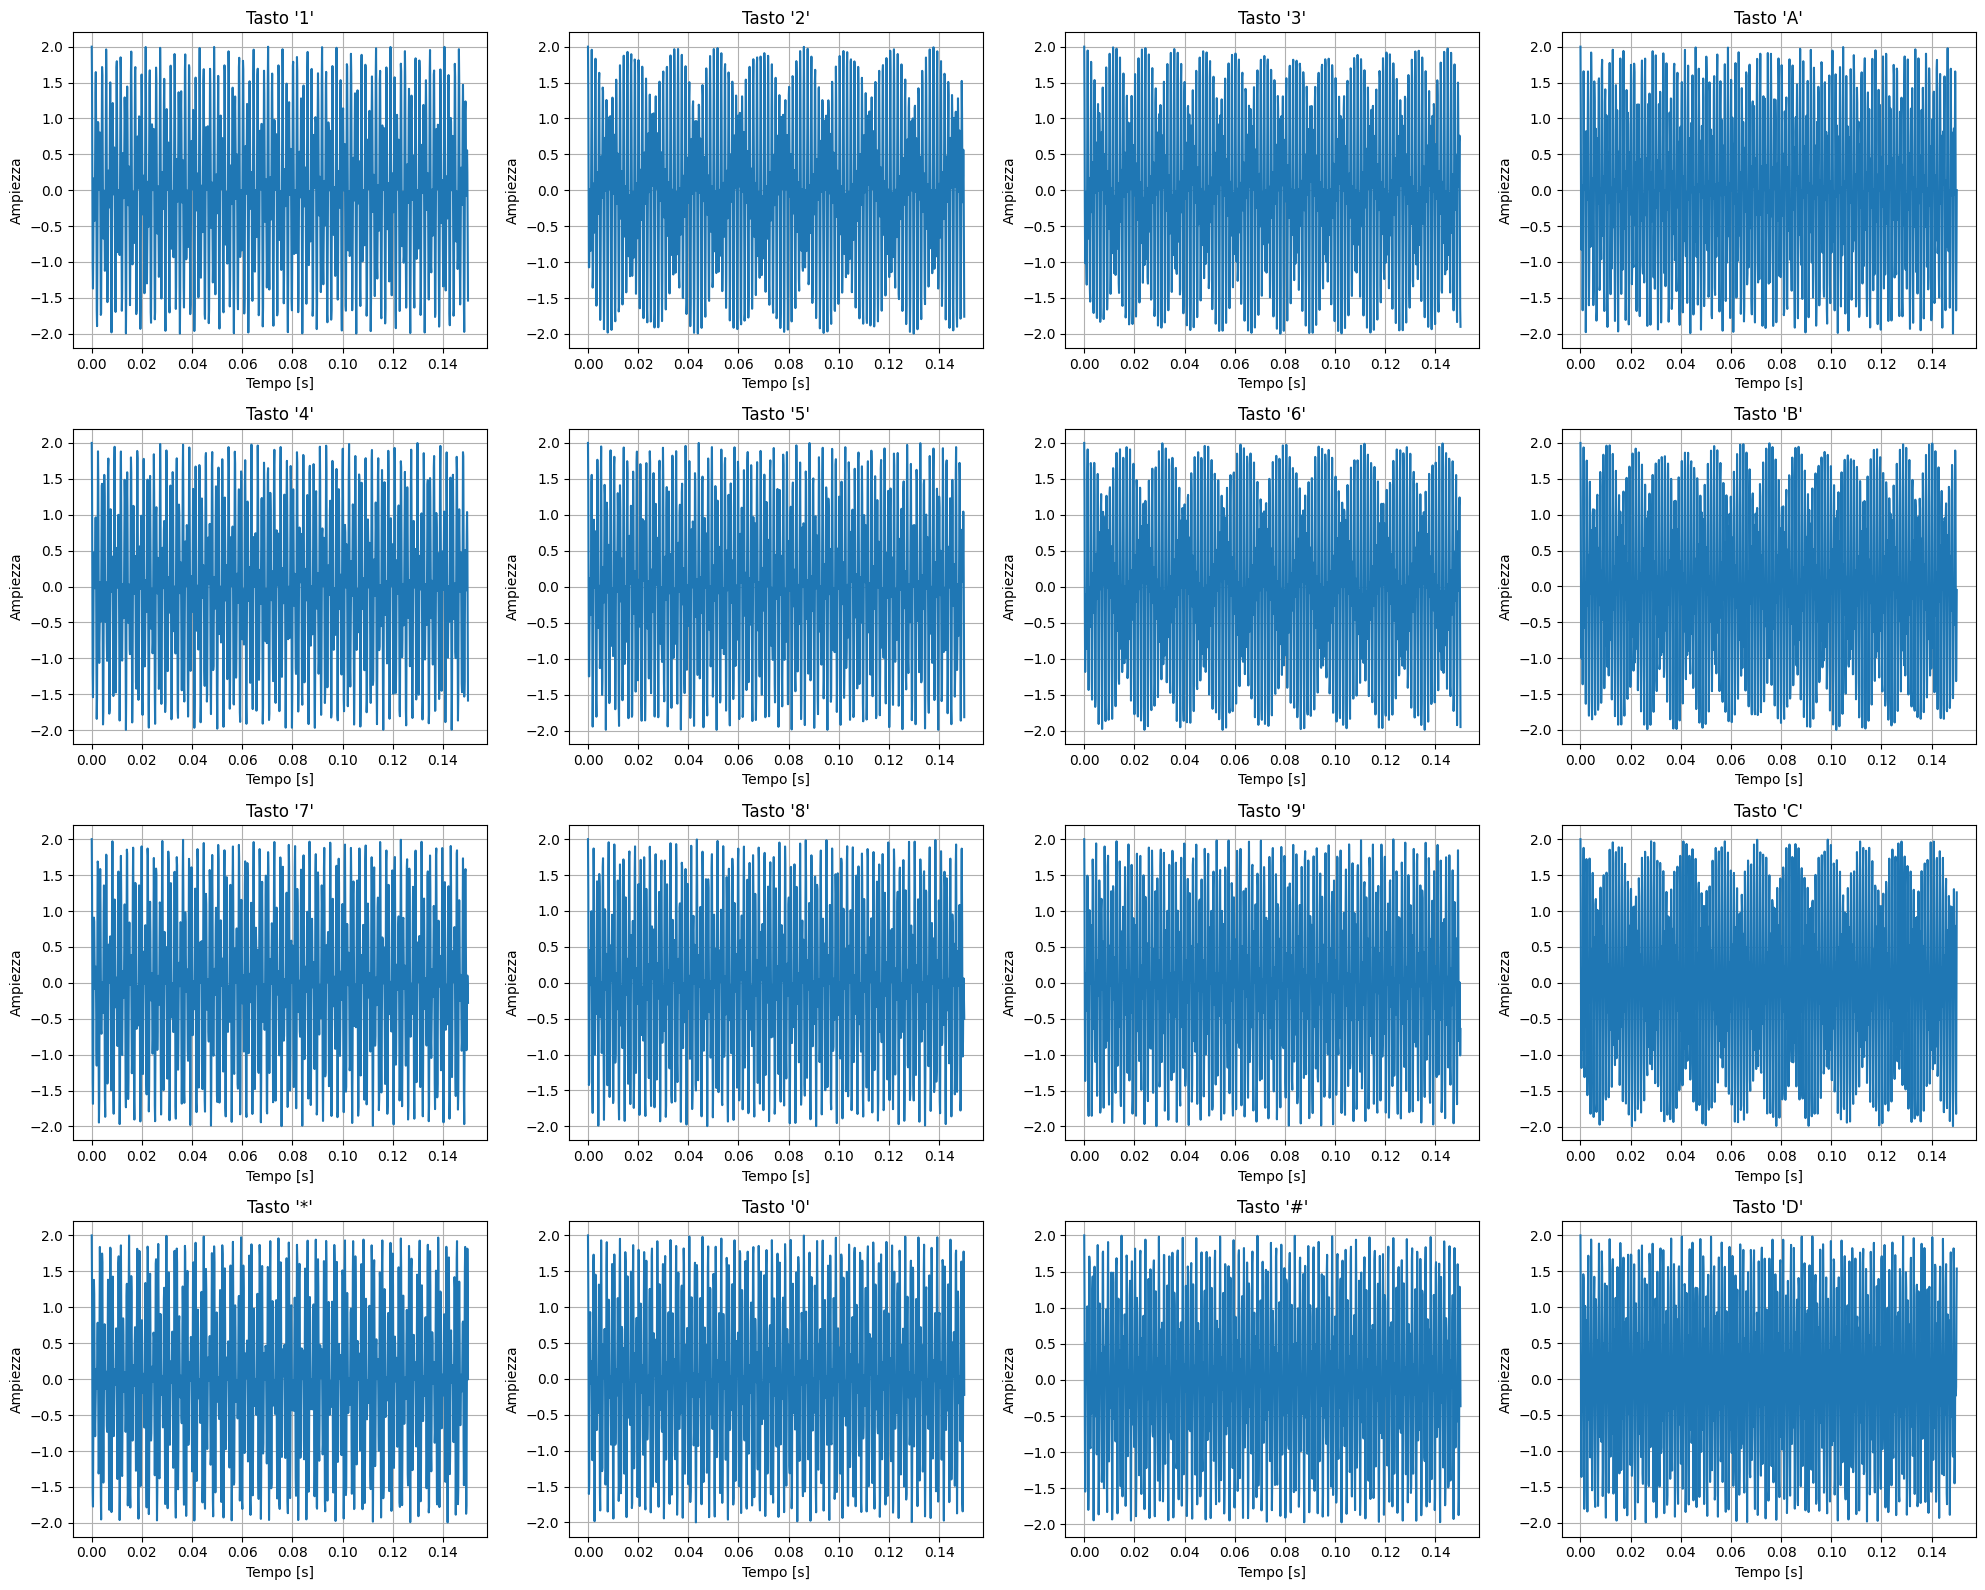

Plot dei segnali nel tempo salvato in: Plots/all_tones/all_tones_time.png


In [ ]:
# Creazione cartella
all_tones_dir = "Plots/all_tones"
os.makedirs(all_tones_dir, exist_ok=True)

# Tastiera
keypad_rows = [
    ['1','2','3','A'],
    ['4','5','6','B'],
    ['7','8','9','C'],
    ['*','0','#','D']
]

# Flatten dei tasti
all_keys = [k for row in keypad_rows for k in row]

# Frequenza di campionamento
Fs = 8000
duration = 0.15

# Plot
fig_time, axes_time = plt.subplots(4, 4, figsize=(20, 16))

for idx, key in enumerate(all_keys):
    
    t, x = tone(key, duration, Fs, F1, F2, tones)

    r = idx // 4
    c = idx % 4
    ax = axes_time[r, c]

    ax.plot(t, x)
    ax.set_title(f"Tasto '{key}'")
    ax.set_xlabel("Tempo [s]")
    ax.set_ylabel("Ampiezza")
    ax.grid(True)
    
plt.tight_layout()

time_plot_path = os.path.join(all_tones_dir, "all_tones_time.png")
fig_time.savefig(time_plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Plot dei segnali nel tempo salvato in:", time_plot_path)

**Plot dei toni nel dominio della frequenza**

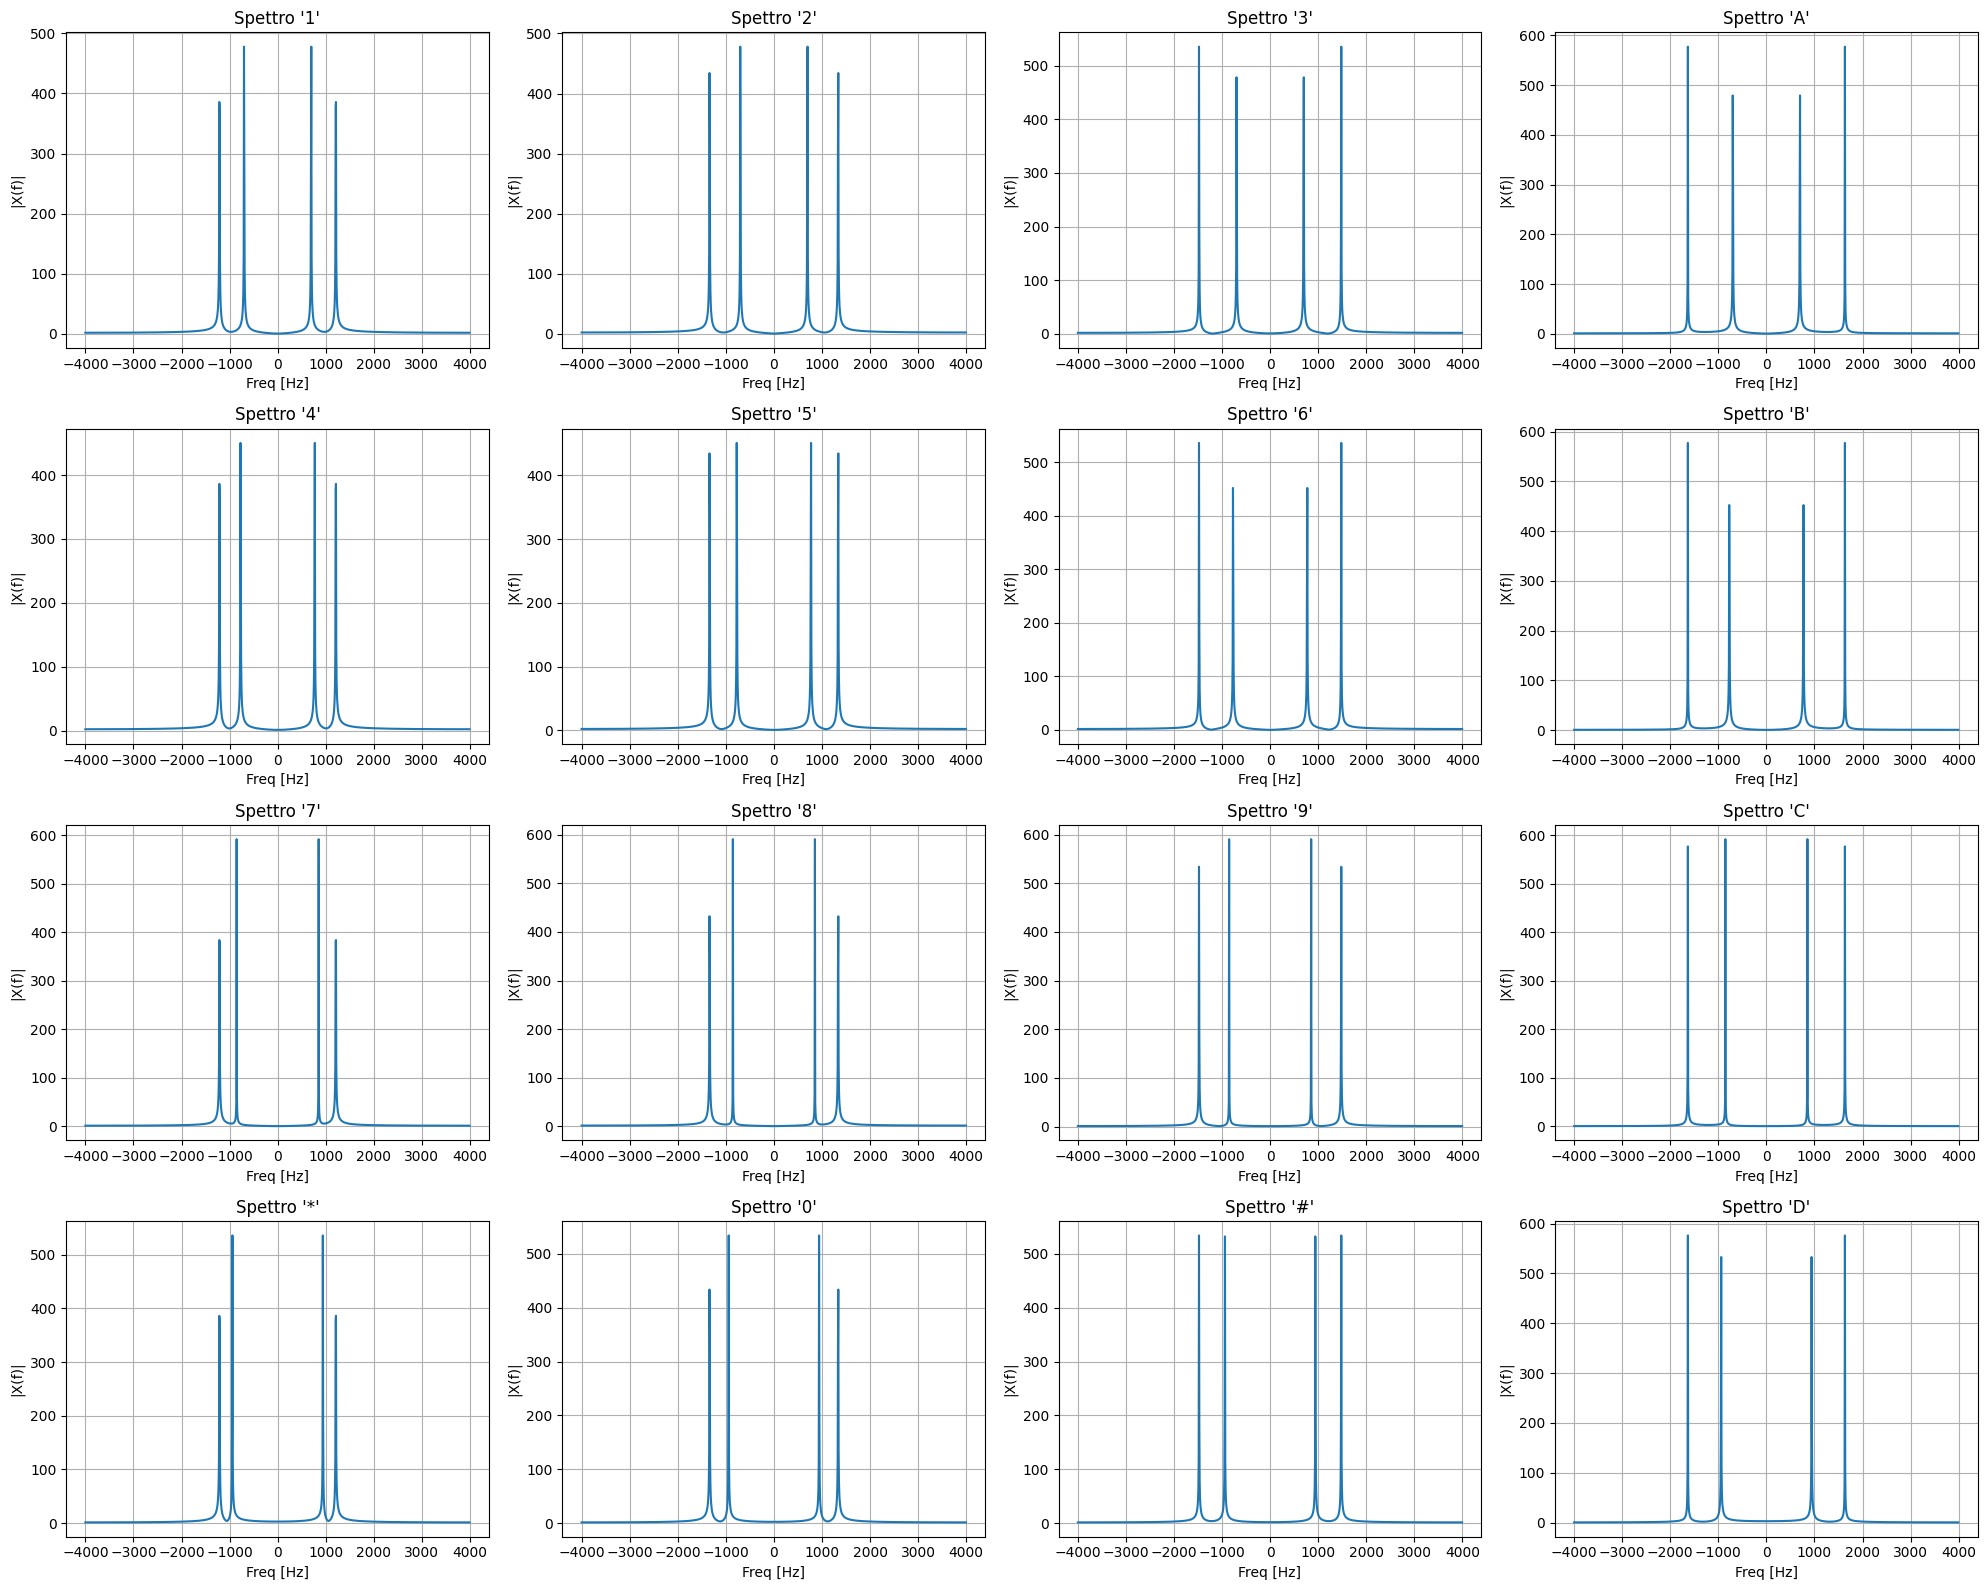

Plot degli spettri salvato in: Plots/all_tones/all_tones_freq.png


In [13]:
# Cartella dove salvare il plot
all_tones_dir = "Plots/all_tones"
os.makedirs(all_tones_dir, exist_ok=True)

fig_freq, axes_freq = plt.subplots(4, 4, figsize=(20, 16))

for r in range(4):
    for c in range(4):
        
        key = keypad_rows[r][c]
        t, x = tone(key, duration, Fs)

        # FFT
        N = len(x)
        X = fft(x)
        X_shifted = fftshift(X)
        freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

        ax = axes_freq[r, c]

        # Spettro (modulo)
        ax.plot(freqs, np.abs(X_shifted))
        ax.set_title(f"Spettro '{key}'")
        ax.set_xlabel("Freq [Hz]")
        ax.set_ylabel("|X(f)|")
        ax.grid(True)

plt.tight_layout()

# Salvataggio
freq_plot_path = os.path.join(all_tones_dir, "all_tones_freq.png")
fig_freq.savefig(freq_plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("Plot degli spettri salvato in:", freq_plot_path)

Plot salvato in: Plots/sequenza.png


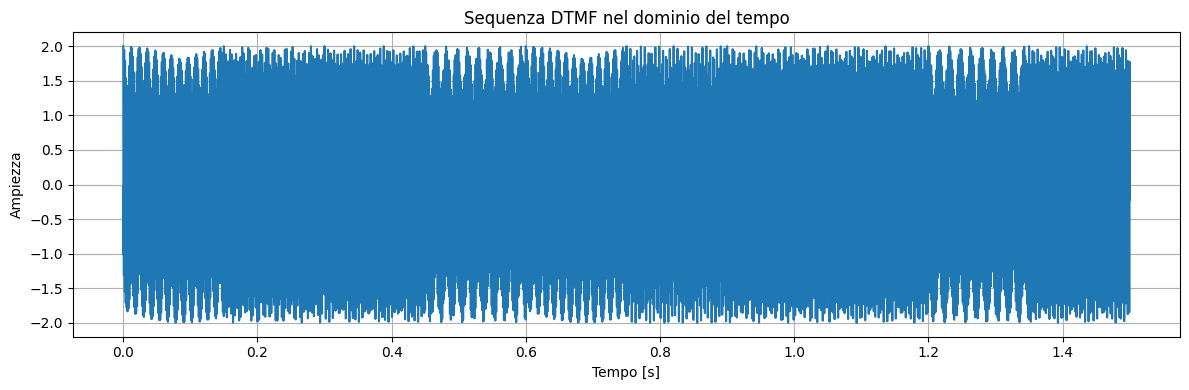

Audio salvato: sequenza.wav
Plot salvato in: Plots/spettro_sequenza.png


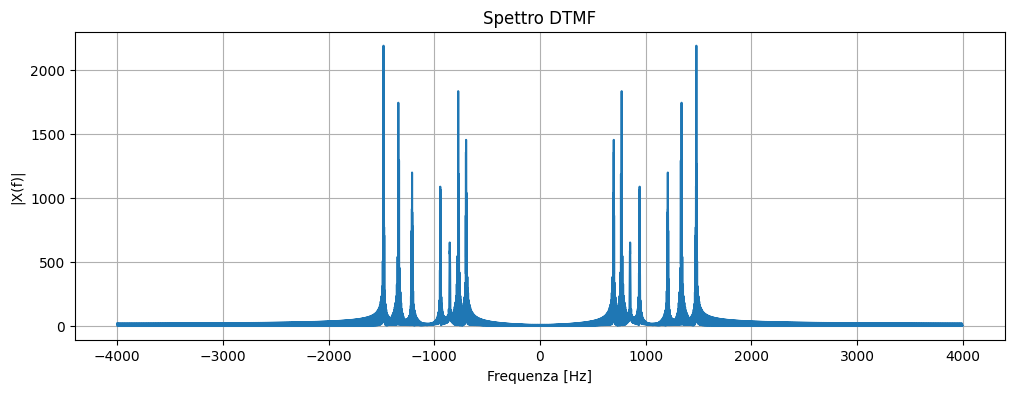

(array([-4000.        , -3999.33333333, -3998.66666667, ...,
         3998.        ,  3998.66666667,  3999.33333333]),
 array([17.50205654-0.j        , -0.43774436-1.24140538j,
         0.0816677 +0.15751167j, ..., -0.41925794-0.93530485j,
         0.0816677 -0.15751167j, -0.43774436+1.24140538j]))

In [14]:
# Generazione e visualizzazione della sequenza '3456318060'
sequenza = "3456318060"
toneDuration = 0.15
full_signal = dialNumber(sequenza, Fs, toneDuration)

plot_and_save_sequence(full_signal, Fs, filename="sequenza.wav", plot_filename="sequenza.png")
# Spettro sequenza
plot_spectrum(full_signal, Fs, plot_filename="spettro_sequenza.png")

In [ ]:
# Riconoscimento della sequenza
detected = recSequence(full_signal, toneDuration=0.15, Fs=8000)
print("Sequenza riconosciuta:", detected)

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


**Inserimento di pause tra un tono e l'altro**

Plot salvato in: Plots/sequenza_pause.png


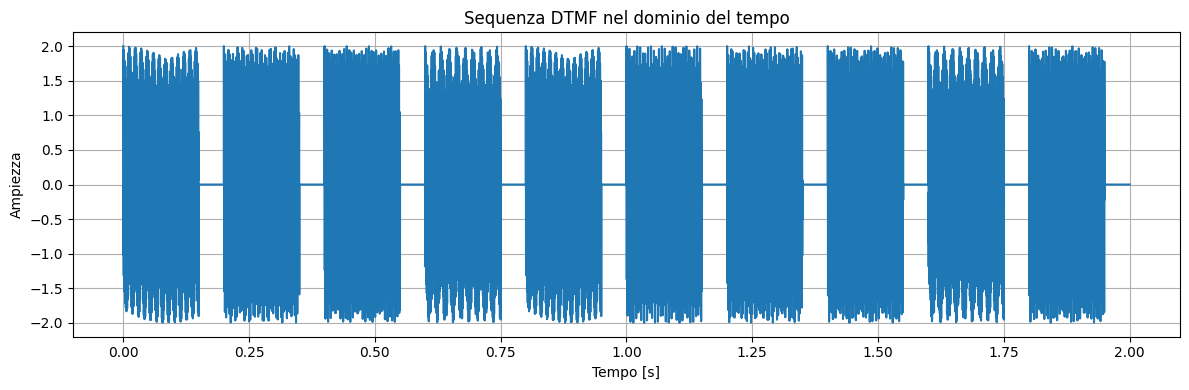

Audio salvato: sequenza_pause.wav
Plot salvato in: Plots/spettro_sequenza_pause.png


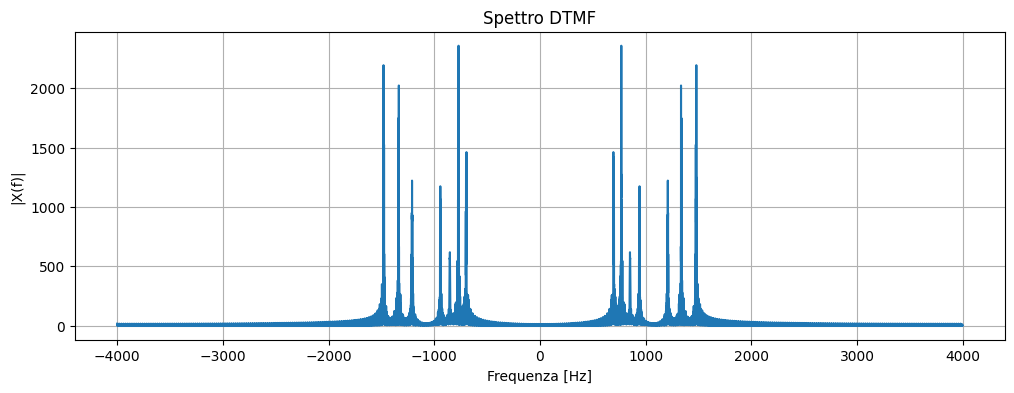

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


In [18]:
full_signal_pauses = dialNumber_pauses(sequenza, Fs, toneDuration, pauseDuration=0.05)

plot_and_save_sequence(full_signal_pauses, Fs, filename="sequenza_pause.wav",
                       plot_filename="sequenza_pause.png")

plot_spectrum(full_signal_pauses, Fs, plot_filename="spettro_sequenza_pause.png")

detected_pauses = detect_sequence_pauses(full_signal_pauses, toneDuration=toneDuration,
                                         pauseDuration=0.05, Fs=Fs, silence_threshold=0.05)

print("Sequenza riconosciuta:", detected_pauses)


Plot salvato in: Plots/spettro_overlay_pause.png


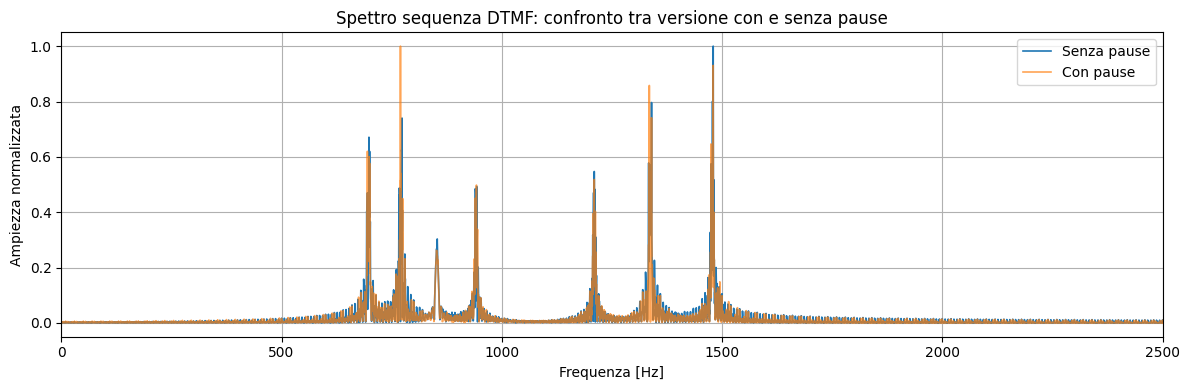

In [19]:
# Lunghezze originali
N_no = len(full_signal)
N_pa = len(full_signal_pauses)

# Lunghezza massima
N = max(N_no, N_pa)

# Padding per allineare le lunghezze
sig_no = np.pad(full_signal, (0, N - N_no), mode='constant')
sig_pa = np.pad(full_signal_pauses, (0, N - N_pa), mode='constant')

# FFT
X_no = fftshift(fft(sig_no))
X_pa = fftshift(fft(sig_pa))

# Ampiezze normalizzate
X_no_norm = np.abs(X_no) / np.max(np.abs(X_no))
X_pa_norm = np.abs(X_pa) / np.max(np.abs(X_pa))

# Asse delle frequenze
freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

# Plot overlay
plt.figure(figsize=(12,4))
plt.plot(freqs, X_no_norm, label="Senza pause", linewidth=1.2)
plt.plot(freqs, X_pa_norm, label="Con pause", alpha=0.7, linewidth=1.2)
plt.xlim(0, 2500)
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Ampiezza normalizzata")
plt.title("Spettro sequenza DTMF: confronto tra versione con e senza pause")
plt.grid(True)
plt.legend()
save_plot("spettro_overlay_pause.png")
plt.show()

## **2. Esperimenti e metodologia**

### **2.1 Variazione della durata del tono**

In [ ]:
# Esegui tutti gli esperimenti sulla durata
results = run_duration_experiments(
    durations=[0.02, 0.05, 0.1, 0.15, 0.2, 0.5],
    Fs=8000,
    n_sequences=100,
    save_folder="Plots_duration"
)

### **2.2 Aggiunta di rumore al segnale**

### **2.3 Variazione della frequenza di campionamento**

## **3. Miglioramenti dell'algoritmo**

### **3.1 Zero-padding**

### **3.2 Filtraggio segnale rumoroso**